# Let Unitree Go2 Robot Dog Trotting and Walking
Import mujoco for simulation, jax for differentiable programming, brax for environment definition and mediapy for visualization.
Feel free to use other familiar libraries for illustration.

In [12]:
import subprocess

# subprocess.run(['/usr/local/bin/python3', '-m', 'pip', 'install', 'brax'], check=True)
# subprocess.run(['/usr/local/bin/python3', '-m', 'pip', 'install', 'mediapy'], check=True)

In [13]:
import mujoco
import jax
import jax.numpy as jnp

from jax import config
config.update("jax_debug_nans", True)
config.update("jax_enable_x64", True)
config.update('jax_default_matmul_precision', 'high')

from brax.envs.base import Env, PipelineEnv, State
from brax.io import html, mjcf, model
from IPython.display import HTML

import numpy as np
import matplotlib.pyplot as plt
import mediapy as media

Define an RL environment for quadrupedal locomotion for Unitree Go2 robot dog. The mujoco xml file can also be found from mujoco_menagerie library which hosts a zoo of robot models. Override the actuator gain to make the commanded motion better tracked. 

In [14]:
class QuadrupedUnitreeGo2(PipelineEnv):
    def __init__(self, **kwargs):
        self.mj_model = mujoco.MjModel.from_xml_path('unitree_go2/scene_mjx.xml')
        kp = 230
        self.mj_model.actuator_gainprm[:, 0] = kp
        self.mj_model.actuator_biasprm[:, 1] = -kp
        sys = mjcf.load_model(self.mj_model)
        physics_steps_per_control_step = 5
        kwargs['n_frames'] = kwargs.get('n_frames', physics_steps_per_control_step)
        kwargs['backend'] = 'mjx'

        super().__init__(sys, **kwargs)

        # added cache sensor / body lookups + nominal standing height
        sid = self.mj_model.sensor('global_linvel').id
        self._linvel_adr = self.mj_model.sensor_adr[sid]
        self._linvel_dim = self.mj_model.sensor_dim[sid]
        self._base_id = self.mj_model.body('base').id
        self._z_target = float(self.mj_model.keyframe('home').qpos[2])

    def reset(self, rng):
        init_qpos = self.mj_model.keyframe('home').qpos
        #init_qpos[2] += 0.1
        qpos = jnp.array(init_qpos)
        qvel = jnp.zeros((self.sys.nv,))

        data = self.pipeline_init(qpos, qvel)

        obs = self._get_obs(data)

        metrics = {
            'joint_pos_reward': 0.0,
            'base_height_reward': 0.0,
            'base_orient_reward': 0.0,
            'base_linvel_reward': 0.0,
            # 'base_pos_reward': r_pos,
        }
        return State(data, obs, 0.0, False, metrics)

    def _get_obs(self, data):
        #extract interested observations from state data
        position = data.qpos
        position = position[7:] #exclude the first free base link, keep only 1-dof joint position can be measured by encoders
        
        #IMU readings for base link
        sensor_id = self.mj_model.sensor('global_linvel').id
        sensor_adr = self.mj_model.sensor_adr[sensor_id]
        sensor_dim = self.mj_model.sensor_dim[sensor_id]
        base_linvel = data.sensordata[sensor_adr:sensor_adr+sensor_dim]    #count the index for global_linvel sensor
        
        base_rot = data.xmat[self.mj_model.body('base').id]

        return jnp.concatenate([
            position,
            base_linvel,
            base_rot.ravel(),
        ])

    def step(self, state, action):
        data = state.pipeline_state
        new_data = self.pipeline_step(data, action)
        obs = self._get_obs(new_data)

        # pull relevant info for reward calculation
        base_linvel = new_data.sensordata[self._linvel_adr:self._linvel_adr + self._linvel_dim]
        v_x = base_linvel[0]                        # linear velocity (world x)
        # x = new_data.qpos[0]
        z = new_data.qpos[2]                        # height (free joint z)
        base_rot = new_data.xmat[self._base_id]     # orientation (rotation matrix of the base link)
        R02 = base_rot[0,2]                         # world-frame x/z of body z-axis
        R12 = base_rot[1,2]                         # world-frame y/z of body z-axis
        
        # weights
        w_vel =100.0
        # w_pos = 10.0
        w_height = 50.0
        w_orient = 1.0

        # reward terms
        r_vel = w_vel * v_x
        # r_pos = w_pos * (x - 0.5)
        r_height = -w_height * (z - self._z_target) ** 2
        r_orient = -w_orient * (R02 ** 2 + R12 ** 2)

        # reward design
        reward = r_vel + r_height + r_orient

        state.metrics.update({
            # 'base_pos_reward': r_pos,
            'base_linvel_reward': r_vel,
            'base_height_reward': r_height,
            'base_orient_reward': r_orient,
            'joint_pos_reward': 0.0,
        })

        return state.replace(pipeline_state=new_data, obs=obs, reward=reward, done=False)

## Part 3 - Trajectory optimization

We prepare initialization of trajectory with the cyclic motion insight. This is from a [tutorial](https://colab.research.google.com/github/google-deepmind/mujoco/blob/main/mjx/training_apg.ipynb) and originated from [Marc Raibert](https://en.wikipedia.org/wiki/Marc_Raibert)'s heuristic. 

Then we refine it with gradient descent through the differentiable simulator. The total rollout reward is computed with `jax.lax.scan` over the physics steps, and `jax.grad` gives $\nabla_{\mathbf{u}_{0:T-1}}\, -\!\sum_t r_t$ via reverse-mode autodiff.

### Trotting reference (initial guess)

In [15]:
duration = 4
framerate = 50

env = QuadrupedUnitreeGo2()

jit_step = jax.jit(env.step)

#make trott gait. reference from train_apg example of mjx
def cos_wave(t, step_period, scale):
    _cos_wave = -jnp.cos(((2 * jnp.pi) / step_period) * t)
    return _cos_wave * (scale / 2) + (scale / 2)


def dcos_wave(t, step_period, scale):
    """
    Derivative of the cos wave, for reference velocity
    """
    return ((scale * jnp.pi) / step_period) * jnp.sin(((2 * jnp.pi) / step_period) * t)


def make_kinematic_ref(sinusoid, step_k, scale=0.3, dt=1 / 50):
    """
    Makes trotting kinematics for the 12 leg joints.
    step_k is the number of timesteps it takes to raise and lower a given foot.
    A gait cycle is 2 * step_k * dt seconds long.
    """

    _steps = jnp.arange(step_k)
    step_period = step_k * dt
    t = _steps * dt

    wave = sinusoid(t, step_period, scale)
    # Commands for one step of an active front leg
    fleg_cmd_block = jnp.concatenate(
        [jnp.zeros((step_k, 1)),
         wave.reshape(step_k, 1),
         -2 * wave.reshape(step_k, 1)],
        axis=1
    )
    # Unitree Go2 has joints inverse to Anymal
    h_leg_cmd_bloc = 1 * fleg_cmd_block

    block1 = jnp.concatenate([
        jnp.zeros((step_k, 3)),
        fleg_cmd_block,
        h_leg_cmd_bloc,
        jnp.zeros((step_k, 3))],
        axis=1
    )

    block2 = jnp.concatenate([
        fleg_cmd_block,
        jnp.zeros((step_k, 3)),
        jnp.zeros((step_k, 3)),
        h_leg_cmd_bloc],
        axis=1
    )
    # In one step cycle, both pairs of active legs have inactive and active phases
    step_cycle = jnp.concatenate([block1, block2], axis=0)
    return step_cycle


Check the cyclic reference motion by directly apply it to the robot. It generates some trotting but slightly backward motion since the reference motion is treated as joint trajectories in free space without considering ground contacts.

In [16]:
kin_ref_qpos = make_kinematic_ref(cos_wave, 25, 0.3, 1./50) + jnp.array(env.mj_model.keyframe('home').qpos[7:])
kin_ref_qpos = jnp.concatenate([ kin_ref_qpos for _ in range(12)], axis=0)

state = env.reset(jax.random.PRNGKey(0))
rollout = [state.pipeline_state]
t = 0
while t < kin_ref_qpos.shape[0]:
  ctrl = jnp.array(kin_ref_qpos[t, :])
  state = jit_step(state, ctrl)
#   print(state.pipeline_state.qpos)
  rollout.append(state.pipeline_state)
  t+=1

html_str = html.render(env.sys, [s for s in rollout])

with open('rollout1.html', 'w') as f:
    f.write(html_str)
print("Saved to rollout1.html")

# display(HTML(html_str))
# media.show_video(env.render(rollout), fps=1.0/env.dt)

Saved to rollout1.html


### Build the loss and gradient

Wrappers to make loss function and gradient compatible with jax compilation. 

In [17]:
def _simulate_rollout(init_state, ctrl_array):

    def _scan_step(carry, input):
        new_state = jit_step(carry, input)
        return new_state, new_state
    
    state_final, state_traj = jax.lax.scan(_scan_step, init_state, ctrl_array)
    return state_traj

def rollout_loss(ctrl_array):
    init_state = env.reset(jax.random.PRNGKey(0))
    state_rollout = _simulate_rollout(init_state, ctrl_array)

    def _scan_cost(carry, input):
        tol = carry
        cost = -input.reward
        tol += cost
        return tol, cost
    
    tol_loss, cost_array = jax.lax.scan(_scan_cost, 0.0, state_rollout)
    return tol_loss

jit_loss_fun = jax.jit(lambda ctrl_array: rollout_loss(ctrl_array.reshape((-1, 12))))
jit_loss_grad = jax.jit(jax.grad(jit_loss_fun))

Sanity check and compile jitted functions for the first run.

In [18]:
# Checking if the loss and gradient functions are reasonable
# print(jit_loss_fun(kin_ref_qpos.ravel()))
# print(jit_loss_grad(kin_ref_qpos.ravel()))

### Gradient descent loop

A simple gradient descent to refine the trotting motion for motving forward. Feel free to try other optimization techniques and learning rate.

In [19]:
def train_dog(kin_ref_qpos, jit_loss_fun, jit_loss_grad, learning_rate=1e-3, n_iters=500, clip_norm=5.0):
    ctrl = kin_ref_qpos.ravel()
    loss_history = []

    for i in range(n_iters):
        loss = jit_loss_fun(ctrl)
        grad = jit_loss_grad(ctrl)
        gnorm = jnp.linalg.norm(grad)
        grad = np.where(gnorm > clip_norm, grad * (clip_norm/gnorm), grad)
        ctrl = ctrl - learning_rate * grad

        loss_history.append(float(loss))
        # for verifying loss + gradient
        if i % 10 == 0:
            print(f"iter {i:4d}: loss = {float(loss):+9.4f}   |grad| = {float(gnorm):8.4f}")

    return ctrl, loss_history

iter    0: loss = +1949.8484   |grad| = 19419.9611
iter   10: loss = +1526.2861   |grad| = 19509.0478
iter   20: loss = +1036.7133   |grad| = 17668.5110
iter   30: loss = +616.3059   |grad| = 17686.6513
iter   40: loss = +235.4922   |grad| = 18476.7018
iter   50: loss =  -62.8375   |grad| = 16359.0490
iter   60: loss = -462.0135   |grad| = 20441.4937
iter   70: loss = -687.6701   |grad| = 19269.7098
iter   80: loss = -951.9353   |grad| = 22528.8392
iter   90: loss = -1120.2665   |grad| = 24230.6761
iter  100: loss = -1060.1807   |grad| = 26170.1916
iter  110: loss = -1267.6170   |grad| = 22925.6063
iter  120: loss = -1524.2402   |grad| = 24587.0026
iter  130: loss = -1744.2926   |grad| = 23369.8890
iter  140: loss = -1660.3109   |grad| = 25456.2079
iter  150: loss = -1954.4617   |grad| = 25173.6031
iter  160: loss = -2102.9302   |grad| = 26249.8984
iter  170: loss = -2305.7985   |grad| = 22139.8664
iter  180: loss = -2474.5262   |grad| = 29488.3266
iter  190: loss = -2582.5427   |grad|

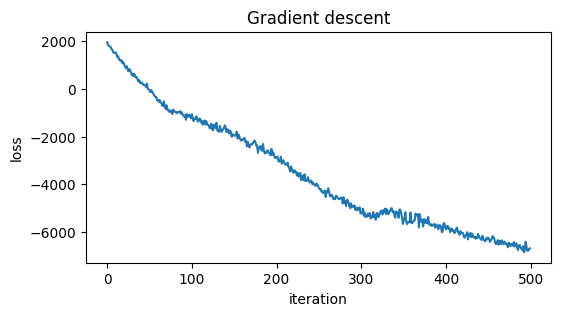

In [20]:
ctrl, loss_history = train_dog(kin_ref_qpos, jit_loss_fun, jit_loss_grad)

plt.figure(figsize=(6, 3))
plt.plot(loss_history)
plt.xlabel('iteration'); plt.ylabel('loss')
plt.title('Gradient descent')
plt.show()

### Roll out the optimized control and check forward progress

In [21]:
state = env.reset(jax.random.PRNGKey(0))
rollout = [state.pipeline_state]
ctrl_seq = ctrl.reshape((-1, 12))

# Store total forward movement and height fluctuations
x_pos = [float(state.pipeline_state.qpos[0])]
z_pos = [float(state.pipeline_state.qpos[2])]

t = 0
while t < ctrl_seq.shape[0]:
    state = jit_step(state, ctrl_seq[t])
    rollout.append(state.pipeline_state)
    x_pos.append(float(state.pipeline_state.qpos[0]))
    z_pos.append(float(state.pipeline_state.qpos[2]))
    t+=1

print(f"Trunk x: {x_pos[0]:+.2f}m -> {x_pos[-1]:+.2f}m")
print(f"Trunk z (height) min/mean/max: {min(z_pos):.3f} / {np.mean(z_pos):.3f} / {max(z_pos):.3f} m")

# media.show_video(env.render(rollout), fps=1.0 / env.dt)
html_str = html.render(env.sys, [s for s in rollout])

with open('rollout2.html', 'w') as f:
    f.write(html_str)
print("Saved to rollout2.html")

# display(HTML(html_str))

Trunk x: +0.00m -> +0.65m
Trunk z (height) min/mean/max: 0.254 / 0.268 / 0.295 m
Saved to rollout2.html


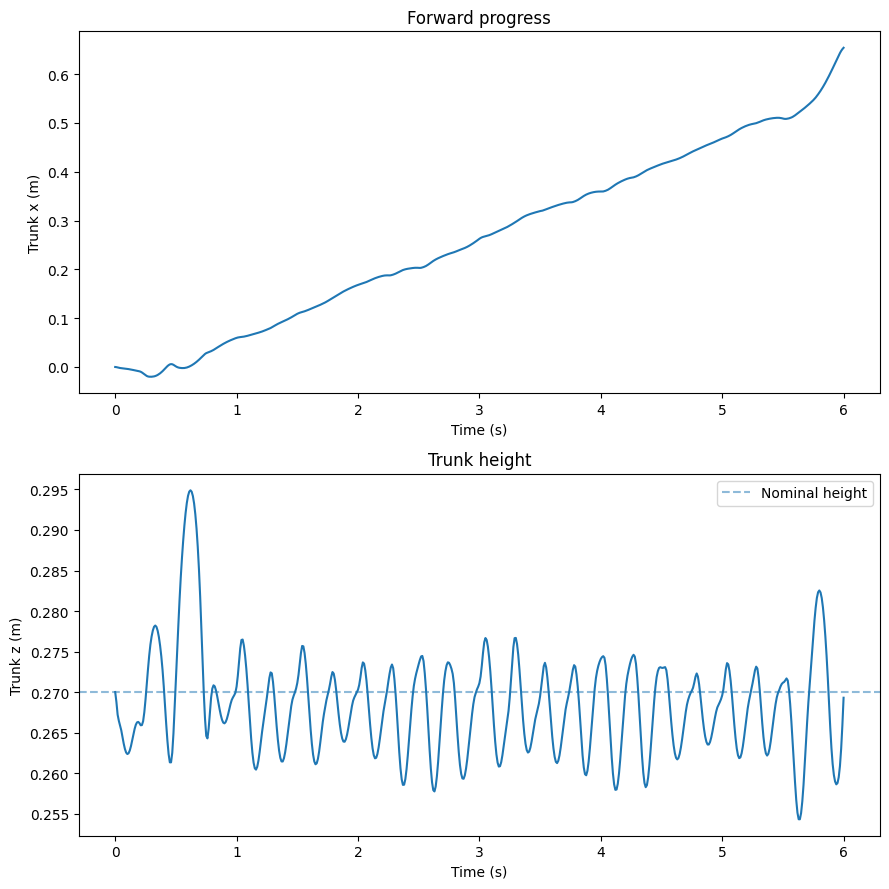

In [31]:
t_axis = np.arange(len(x_pos)) * env.dt
fig, axes = plt.subplots(2, 1, figsize=(9, 9))
axes[0].plot(t_axis, x_pos)
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Trunk x (m)')
axes[0].set_title('Forward progress')

axes[1].plot(t_axis, z_pos)
axes[1].axhline(env._z_target, ls='--', alpha=0.5, label='Nominal height')
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('Trunk z (m)')
axes[1].set_title('Trunk height')
axes[1].legend()

plt.tight_layout()
plt.show()